In [1]:
from __future__ import print_function

import sys
import random
import ftplib
from datetime import datetime, timedelta
from io import BytesIO

import pandas as pd
import pytz

sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import sql_functions, dataframe_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

sys.path.append("/var/www/python/Prod/SPP/DataDownload/LMP/")
from spp_update_lmp_summary import run_cron_job_summaries

# Config
FTP_HOST = 'pubftp-mte.itespp.org'
FTP_BASE = '/Markets/DA/LMP_By_SETTLEMENT_LOC'
# Per-day file path under FTP_BASE: YYYY/MM/By_Day/DA-LMP-SL-YYYYMMDD0100.csv
TZ = pytz.timezone('America/Chicago')



In [2]:
"""
:Author: Qingcheng Wei
Date: 03/04/2026


Objective:
    Download SPP Mid-Term Wind Forecast (MTWF) and Mid-Term Solar Forecast (MTSF) data.
    Parse ONLY the LATEST downloaded CSV file and update the database tables:

    Intermediate table:
    - spp_physical.MTWF                               (added baa_zone; PK: ForecastTime, IntervalEnd, baa_zone)

    Per-BAA output tables:
    - spp_physical.baa_zonal_latest_wind_forecast     (latest wind forecast per BAA zone; PK: dt, hr, baa_zone)
    - spp_physical.baa_zonal_virtual_wind_forecast    (virtual wind forecast per BAA zone; PK: dt, hr, baa_zone)
    - spp_physical.baa_zonal_latest_solar_forecast    (latest solar forecast per BAA zone; PK: dt, hr, baa_zone)
    - spp_physical.baa_zonal_virtual_solar_forecast   (virtual solar forecast per BAA zone; PK: dt, hr, baa_zone)

    Market-total output tables:
    - spp_physical.spp_latest_wind_forecast           (latest wind forecast summed across all BAA zones; PK: dt, hr)
    - spp_physical.spp_virtual_wind_forecast          (virtual wind forecast summed across all BAA zones; PK: dt, hr)
    - spp_physical.spp_latest_solar_forecast          (latest solar forecast summed across all BAA zones; PK: dt, hr)
    - spp_physical.spp_virtual_solar_forecast         (virtual solar forecast summed across all BAA zones; PK: dt, hr)

Data Source: ftp://pubftp.spp.org/Operational_Data/MTRF/

Calling this program:
    python spp_dataDownload_MTWF.py [START_DATE] [END_DATE]
    If dates are not provided, it defaults to yesterday and today.
"""

import sys
import os
import glob
import pandas as pd
import datetime
import pytz
import subprocess
import shutil

# Add project path for custom modules
sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import connections, sql_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

script_name= 'spp_dataDownload_MTWF.py'

# Define the set of columns that are essential for the script to function.
ESSENTIAL_MTWF_COLUMNS = {
    'Interval',
    'GMTIntervalEnd',
    'Wind Forecast MW',
    'Solar Forecast MW'
}

# When BAA column is present, map its value to the baa_zone code stored in the DB.
# Old-format files that lack BAA are treated as SPP (East).
BAA_ZONE_MAP = {
    'SPP':  'E',
    'SWPW': 'W',
}


def log_message(level, type, line, message):
    print(f"{level} - {type} - Line {line}: {message}")

def download_forecast(dt):
    try:
        download_folder = "/var/www/python/Qingcheng/ActualWind/"
        if not os.path.exists(download_folder):
            try:
                os.makedirs(download_folder)
            except OSError as e:
                print(f"Error creating directory {download_folder}: {e}")
                return

        dt_str = dt.strftime("%Y/%m/%d")
        ftp_url = f"ftp://pubftp-mte.itespp.org/Operational_Data/MTRF/{dt_str}"

        # Using wget to download files recursively, no directories, no clobber
        cmd = f"wget -nd -r -nc {ftp_url} -P {download_folder}"
        print(f"Executing: {cmd}")
        subprocess.run(cmd, shell=True)

        # List files in the directory
        files = glob.glob(os.path.join(download_folder, "*"))

        # Filter files based on name pattern
        mtlf_files = [f for f in files if ('MTRF' in os.path.basename(f) or 'DAWF' in os.path.basename(f) or 'MTWF' in os.path.basename(f))]

        if not mtlf_files:
            print('no file been found')
            return

        mtlf_files.sort(key=lambda x: ''.join(filter(str.isdigit, os.path.basename(x))))
        # Now that it's sorted, the LATEST timestamp is the LAST item
        latest_file = mtlf_files[7]
        print(f"\nLatest file identified: {os.path.basename(latest_file)}")

        # Process ONLY the latest file
        return process_file(latest_file)
        

    finally:
        if os.path.exists(download_folder):
            shutil.rmtree(download_folder)
            print(f"Cleanup: Folder {download_folder} has been removed.")


def process_file(file_path):
    global warning_string
    file_name = os.path.basename(file_path)
    print(f"\n--- Processing File: {file_name} ---")

    # Extract time from filename (digits only) + "00"
    time_of_file = ''.join(filter(str.isdigit, file_name))
    time_of_file += "00"
    print(f"time of file is {time_of_file}")

    # Read and clean column names
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]

    actual_columns = set(df.columns)
    expected_columns=ESSENTIAL_MTWF_COLUMNS
    known_optional_columns = {'BAA'}

    # Check for column mismatches and handle them.
    if not expected_columns.issubset(actual_columns):
        missing_cols = expected_columns - actual_columns
        exception_str = (
            f"\n[ERROR] File '{file_path}' has schema mismatch. "
            f"Missing essential columns: {missing_cols}. "
            f"Skipping file.\n"
        )
        warning_string += exception_str
        print(exception_str.strip())
        return

    truly_new_cols = actual_columns - expected_columns - known_optional_columns
    if truly_new_cols:
        warning_string += f"\n[INFO] File '{file_path}' has new, unexpected columns: {truly_new_cols}.\n"

    
    # 1. Date Conversion (Vectorized)
    file_date = pd.to_datetime(time_of_file[:8], format='%Y%m%d').date()
    next_day  = file_date + datetime.timedelta(days=1)
    df['IntervalEnd'] = pd.to_datetime(df['Interval'], errors='coerce')
    df['GMTIntervalEnd'] = pd.to_datetime(df['GMTIntervalEnd'], errors='coerce')

    df = df[df['IntervalEnd'].dt.date == next_day].copy()
    # Drop rows where date parsing failed
    df.dropna(subset=['IntervalEnd', 'GMTIntervalEnd'], inplace=True)

    # 2. Process and Coalesce Wind Forecast Data (Vectorized)
    df['MTWF'] = pd.to_numeric(df.get('Wind Forecast MW'), errors='coerce').fillna(0)

    # 3. Process Solar Forecast Data (Vectorized)
    df['MTSF'] = pd.to_numeric(df.get('Solar Forecast MW'), errors='coerce').fillna(0)

    # 4. Add ForecastTime
    df['ForecastTime'] = pd.to_datetime(time_of_file, format='%Y%m%d%H%M%S')

    # 5. Derive baa_zone: 'E' for SPP, 'W' for SWPW.
    # Old-format files that lack the BAA column default to 'E' (SPP only).
    if 'BAA' in df.columns:
        df['baa_zone'] = df['BAA'].str.strip().map(BAA_ZONE_MAP)
        unknown_baa = df['baa_zone'].isna() & df['BAA'].notna()
        if unknown_baa.any():
            bad_vals = df.loc[unknown_baa, 'BAA'].unique().tolist()
            warning_string += (
                f"\n[WARNING] File '{file_path}' contains unrecognised BAA values: {bad_vals}. "
                f"Rows will be skipped.\n"
            )
        df.dropna(subset=['baa_zone'], inplace=True)
    else:
        df['baa_zone'] = 'E'

    # 6. Filtering (Vectorized)
    df_filtered = df[df['IntervalEnd'].dt.year > 2000].copy()

    # 7. Final Formatting and Upload
    df_filtered['IntervalEnd'] = df_filtered['IntervalEnd'].dt.strftime('%Y-%m-%d %H:%M:%S')
    df_filtered['GMTIntervalEnd'] = df_filtered['GMTIntervalEnd'].dt.strftime('%Y-%m-%d %H:%M:%S')
    df_filtered['ForecastTime'] = df_filtered['ForecastTime'].dt.strftime('%Y-%m-%d %H:%M:%S')

    df_upload = df_filtered[['ForecastTime', 'IntervalEnd', 'GMTIntervalEnd', 'MTWF', 'MTSF', 'baa_zone']]
    print(f"Rows found: {len(df_upload)}")

    sql_functions.replace_into_sql_table(
            df=df_upload,
            final_table_fullname='spp_temp.MTWF_mte',
            print_details=True
        )


def update_latest_tables(start_dt,lookback_days=20):
    start_time=start_dt-datetime.timedelta(days=lookback_days)
    # Update latest wind forecast
    sql_functions.run_sql_query("""
        CREATE TABLE IF NOT EXISTS spp_temp.baa_zonal_latest_wind_forecast_mte (
         `dt` date NOT NULL,
         `hr` tinyint(3) unsigned NOT NULL,
         `baa_zone` char(10) NOT NULL DEFAULT 'E',
         `Gen_MW` float(8,2) DEFAULT NULL,
         PRIMARY KEY (`dt`,`hr`,`baa_zone`)
        ) ENGINE=MyISAM
    """)

    query_wind_latest = f"""
        REPLACE INTO spp_temp.baa_zonal_latest_wind_forecast_mte
        (dt,hr,baa_zone,Gen_MW)
        SELECT date(w.IntervalEnd), hour(w.IntervalEnd)+1, w.baa_zone, NULLIF(w.MTWF, 0)
        FROM
        spp_temp.MTWF_mte w
        JOIN (SELECT IntervalEnd, baa_zone, max(ForecastTime) ForecastTime
        FROM spp_temp.MTWF_mte WHERE IntervalEnd > Date('{start_time.date()}') GROUP BY IntervalEnd, baa_zone) ft
            ON w.IntervalEnd=ft.IntervalEnd AND w.baa_zone=ft.baa_zone AND w.ForecastTime=ft.ForecastTime
    """
    sql_functions.run_sql_query(query_wind_latest)
    print("\ndata updated in latest wind table")


    # Update latest solar forecast
    sql_functions.run_sql_query("""
        CREATE TABLE IF NOT EXISTS spp_temp.baa_zonal_latest_solar_forecast_mte (
         `dt` date NOT NULL,
         `hr` tinyint(3) unsigned NOT NULL,
         `baa_zone` char(10) NOT NULL DEFAULT 'E',
         `Gen_MW` float(8,2) DEFAULT NULL,
         PRIMARY KEY (`dt`,`hr`,`baa_zone`)
        ) ENGINE=MyISAM
    """)

    query_solar_latest = f"""
        REPLACE INTO spp_temp.baa_zonal_latest_solar_forecast_mte
        (dt,hr,baa_zone,Gen_MW)
        SELECT date(w.IntervalEnd), hour(w.IntervalEnd)+1, w.baa_zone, NULLIF(w.MTSF, 0)
        FROM
        spp_temp.MTWF_mte w
        JOIN (SELECT IntervalEnd, baa_zone, max(ForecastTime) ForecastTime
        FROM spp_temp.MTWF_mte WHERE IntervalEnd > Date('{start_time.date()}') GROUP BY IntervalEnd, baa_zone) ft
            ON w.IntervalEnd=ft.IntervalEnd AND w.baa_zone=ft.baa_zone AND w.ForecastTime=ft.ForecastTime
    """
    sql_functions.run_sql_query(query_solar_latest)
    print("\ndata updated in latest solar table")



if __name__ == "__main__":
    # Set timezone
    timezone = pytz.timezone("America/Chicago")

    log_message("Debug", "Information", sys._getframe().f_lineno, "Starting Script\n")

   
    # Ensure main table exists
    sql_functions.run_sql_query("""
            CREATE TABLE IF NOT EXISTS spp_temp.MTWF_mte (
             `ForecastTime` datetime NOT NULL,
             `IntervalEnd` datetime NOT NULL,
             `GMTIntervalEnd` datetime DEFAULT NULL,
             `MTWF` float(10,2) NOT NULL DEFAULT 0.0,
             `MTSF` float(10,2) NOT NULL DEFAULT 0.0,
             `baa_zone` char(10) NOT NULL DEFAULT 'E',
             PRIMARY KEY (`ForecastTime`,`IntervalEnd`,`baa_zone`)
            ) ENGINE=MyISAM
        """)

        # Loop through dates

    ranges=pd.date_range('2026-03-28','2026-03-28')

    for i in ranges:
        current_dt = i
        download_forecast(current_dt)
        # # Update derived tables
    update_latest_tables(current_dt)


Debug - Information - Line 256: Starting Script

Executing: wget -nd -r -nc ftp://pubftp-mte.itespp.org/Operational_Data/MTRF/2026/03/28 -P /var/www/python/Qingcheng/ActualWind/


--2026-03-28 19:35:11--  ftp://pubftp-mte.itespp.org/Operational_Data/MTRF/2026/03/28
           => ‘/var/www/python/Qingcheng/ActualWind/.listing’
Resolving pubftp-mte.itespp.org (pubftp-mte.itespp.org)... 192.200.63.48
Connecting to pubftp-mte.itespp.org (pubftp-mte.itespp.org)|192.200.63.48|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /Operational_Data/MTRF/2026/03 ... done.
==> PASV ... done.    ==> LIST ... done.

     0K .                                                       835K=0.002s

2026-03-28 19:35:11 (835 KB/s) - ‘/var/www/python/Qingcheng/ActualWind/.listing’ saved [1652]

Removed ‘/var/www/python/Qingcheng/ActualWind/.listing’.
--2026-03-28 19:35:11--  ftp://pubftp-mte.itespp.org/Operational_Data/MTRF/2026/03/28/28
           => ‘/var/www/python/Qingcheng/ActualWind/.listing’
==> CWD (1) /Operational_Data/MTRF/2026/03/28 ... done.
==> PASV ... done.    ==> LIST ... done.

     0K .    


Latest file identified: OP-MTRF-202603280700.csv

--- Processing File: OP-MTRF-202603280700.csv ---
time of file is 20260328070000
Rows found: 48
temp.temp_MTWF_mteHITNDJ_0EOR6X
length of dataframe to be updated:  48
Table spp_temp.MTWF_mte updated successfully.
Cleanup: Folder /var/www/python/Qingcheng/ActualWind/ has been removed.

data updated in latest wind table

data updated in latest solar table


In [4]:
rt_value1=sql_functions.download_df_from_sql_db('''select * from spp_temp.settlement_location_rt_hourly_mte''')
rt_value2=sql_functions.download_df_from_sql_db('''select * from spp_lmp.settlement_location_rt_hourly where dt >='2026-03-15' ''')
wind_data = sql_functions.download_df_from_sql_db('''select * from spp_temp.baa_zonal_latest_wind_forecast_mte''')

df_wind= pd.merge(rt_value1,wind_data,left_on=['dt','hr','BAA'], right_on=['dt','hr','baa_zone']).rename(columns={'rt_value':'rt_value_mte'})
df_wind2=pd.merge(rt_value2,df_wind,left_on=['node_num','dt','hr'], right_on=['node_num','dt','hr']).rename(columns={'rt_value':'rt_value_ftp'})

In [34]:
df_wind2['dt']=df_wind2['dt'].astype(str)
df_wind3=df_wind2[df_wind2['node_num']==636]

In [35]:
df_wind3

,dt,hr,node_num,rt_value_ftp,congestional_value_x,marginalloss_value_x,BAA,rt_value_mte,congestional_value_y,marginalloss_value_y,baa_zone,Gen_MW
10320,2026-03-15,1,636,-36.1470,-42.0834,-0.2353,E,-2.92373,-42.381700,-2.055680,E,29831.69
10321,2026-03-15,2,636,-35.8445,-7.4616,1.7260,E,-5.56534,-48.484300,-2.544460,E,29944.72
10322,2026-03-15,3,636,-34.6294,-9.7659,1.7456,E,-6.94934,-37.106900,-2.195640,E,29580.89
10323,2026-03-15,4,636,-31.5527,-19.2307,0.9574,E,-12.20490,-72.921800,-4.487910,E,29057.31
10324,2026-03-15,5,636,-21.2622,-4.6019,1.2981,E,-7.14044,-45.032600,-2.845330,E,28506.20
...,...,...,...,...,...,...,...,...,...,...,...,...
370349,2026-03-27,10,636,-21.1552,-16.8840,0.3841,E,11.88450,0.267192,-1.001670,E,26526.51
370350,2026-03-27,11,636,-20.8008,-12.2674,0.7147,E,10.45070,0.241858,-0.824458,E,26624.09
370351,2026-03-27,12,636,-28.7612,-41.4809,-0.9507,E,5.30647,-43.310100,-3.829830,E,26747.40
370352,2026-03-27,13,636,-24.2727,-15.0149,0.7811,E,12.85250,-46.440500,-4.456080,E,26723.32


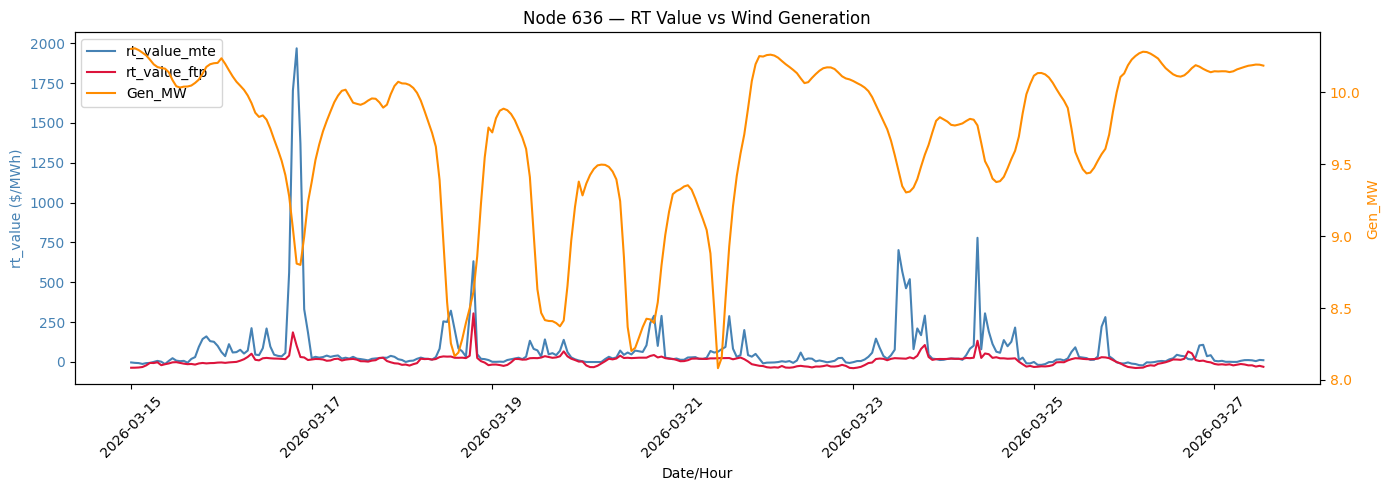

In [38]:
import matplotlib.pyplot as plt
import numpy as np
# Combine dt and hr into a single datetime x-axis
df_plot = df_wind3.copy()
df_plot['datetime'] = pd.to_datetime(df_plot['dt']) + pd.to_timedelta(df_plot['hr'] - 1, unit='h')
df_plot = df_plot.sort_values('datetime')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df_plot['datetime'], df_plot['rt_value_mte'], color='steelblue', label='rt_value_mte')
ax1.plot(df_plot['datetime'], df_plot['rt_value_ftp'], color='crimson', label='rt_value_ftp')
ax1.set_xlabel('Date/Hour')
ax1.set_ylabel('rt_value ($/MWh)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_plot['datetime'], np.log(df_plot['Gen_MW']), color='darkorange', label='Gen_MW')
ax2.set_ylabel('Gen_MW', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Node 636 — RT Value vs Wind Generation')
plt.tight_layout()
plt.show()

In [46]:
df_wind3['wind_bucket'] = pd.cut(df_wind3['Gen_MW'], bins=7)
mte_wind_summary= df_wind3.groupby('wind_bucket')['rt_value_mte'].agg(['mean','min','max']).round(2)
ftp_wind_summary= df_wind3.groupby('wind_bucket')['rt_value_ftp'].agg(['mean','min','max']).round(2)

/tmp/ipykernel_2367182/2701687899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wind3['wind_bucket'] = pd.cut(df_wind3['Gen_MW'], bins=7)
